In [1]:
## Hello there! bitte Ihre eigne dir verwenden.
PROJECT_DIR = "/home/gerko/eeg_blender_project"

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [3]:
mrt=nib.load(f"{PROJECT_DIR}/Data/Raw/mne_data/MNE-sample-data/subjects/sample/mri/brain.mgz")

In [4]:
brain_data = mrt.get_fdata()

In [5]:
print(mrt)


<class 'nibabel.freesurfer.mghformat.MGHImage'>
data shape (np.int32(256), np.int32(256), np.int32(256))
affine:
[[-1.00000000e+00  1.15484021e-07 -1.91852465e-07  1.22726395e+02]
 [ 8.56816911e-08  1.57160827e-08  1.00000000e+00 -1.18960930e+02]
 [ 1.49011647e-08 -1.00000000e+00  6.40284092e-09  1.00712036e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
metadata:
<class 'nibabel.freesurfer.mghformat.MGHHeader'> object, endian='>'
version      : 1
dims         : [256 256 256   1]
type         : 0
dof          : 0
goodRASFlag  : 1
delta        : [1. 1. 1.]
Mdc          : [[-1.0000000e+00  8.5681691e-08  1.4901165e-08]
 [ 1.1548402e-07  1.5716083e-08 -1.0000000e+00]
 [-1.9185246e-07  1.0000000e+00  6.4028409e-09]]
Pxyz_c       : [ -5.273613   9.039085 -27.287964]
tr           : 2300.0
flip_angle   : 0.15707963705062866
te           : 1.6399999856948853
ti           : 1100.0
fov          : 256.0



In [6]:
print ("min:",brain_data.min())
print ("max:",brain_data.max())



min: 0.0
max: 166.0


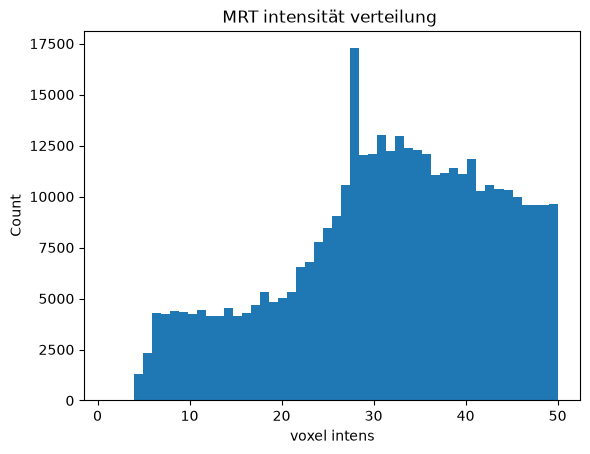

In [7]:
plt.hist(brain_data.flatten(), bins=50, range=(1, 50))
plt.xlabel("voxel intens")
plt.ylabel("Count")
plt.title("MRT intensität verteilung ")
plt.show()



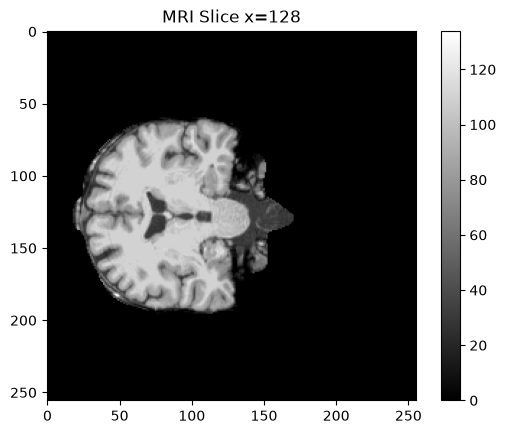

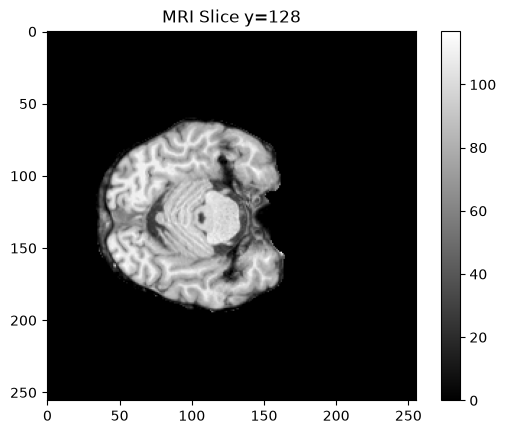

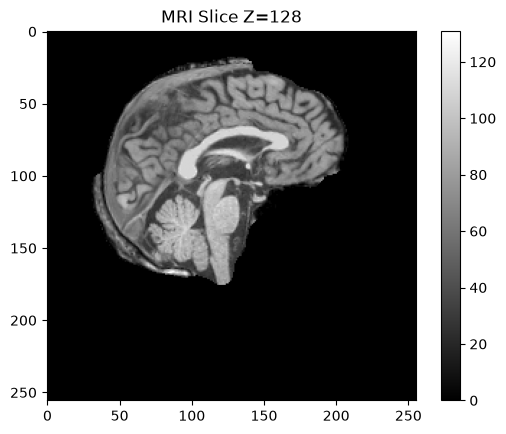

In [8]:
##ndiese code ist nur zu sehen wie die Data aussieht 
slice_index = 128
plt.imshow(brain_data[:,:,slice_index], cmap="gray")
plt.title(f"MRI Slice x={slice_index}")
plt.colorbar()
plt.show()
plt.imshow(brain_data[:, slice_index,:], cmap="gray")
plt.title(f"MRI Slice y={slice_index}")
plt.colorbar()
plt.show()
plt.imshow(brain_data[slice_index, :,:], cmap="gray")
plt.title(f"MRI Slice Z={slice_index}")
plt.colorbar()
plt.show()

In [9]:
import nibabel.freesurfer as nibfs

MNE_DATA_DIR = "/home/gerko/eeg_blender_project/Data/Raw/mne_data/MNE-sample-data"

lh_verts, lh_faces = nibfs.read_geometry(f"{MNE_DATA_DIR}/subjects/sample/surf/lh.pial")
rh_verts, rh_faces = nibfs.read_geometry(f"{MNE_DATA_DIR}/subjects/sample/surf/rh.pial")

print("Left hemisphere:", lh_verts.shape, lh_faces.shape)
print("Right hemisphere:", rh_verts.shape, rh_faces.shape)

Left hemisphere: (155407, 3) (310810, 3)
Right hemisphere: (156866, 3) (313728, 3)


In [10]:
import trimesh

target = 0.3  # keep 30% of faces

mesh_lh = trimesh.Trimesh(vertices=lh_verts, faces=lh_faces)
mesh_lh = mesh_lh.simplify_quadric_decimation(face_count=int(len(lh_faces) * target))
lh_verts, lh_faces = np.array(mesh_lh.vertices), np.array(mesh_lh.faces)

mesh_rh = trimesh.Trimesh(vertices=rh_verts, faces=rh_faces)
mesh_rh = mesh_rh.simplify_quadric_decimation(face_count=int(len(rh_faces) * target))
rh_verts, rh_faces = np.array(mesh_rh.vertices), np.array(mesh_rh.faces)

print("LH after decimation:", lh_verts.shape, lh_faces.shape)
print("RH after decimation:", rh_verts.shape, rh_faces.shape)

LH after decimation: (46623, 3) (93242, 3)
RH after decimation: (47061, 3) (94118, 3)


In [11]:
all_verts = np.vstack([lh_verts, rh_verts])
center = all_verts.mean(axis=0)

lh_verts_centered = (lh_verts - center) / 100
rh_verts_centered = (rh_verts - center) / 100

np.save(f"{PROJECT_DIR}/Data/processed/MRT/lh_pial.npy", lh_verts_centered.astype(np.float32))
np.save(f"{PROJECT_DIR}/Data/processed/MRT/lh_faces.npy", lh_faces.astype(np.int32))
np.save(f"{PROJECT_DIR}/Data/processed/MRT/rh_pial.npy", rh_verts_centered.astype(np.float32))
np.save(f"{PROJECT_DIR}/Data/processed/MRT/rh_faces.npy", rh_faces.astype(np.int32))

Saved!
